# Setup

In [ ]:
!pip install pyturf

In [ ]:
import cuml.accel
cuml.accel.install()

In [ ]:
from google.colab import drive
import os
import requests
from rich.progress import track
import pandas as pd
import numpy as np
import ast
from shapely import wkt
from turf import centroid, Feature
import torch
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
drive.mount('/content/drive')
DRIVE_FOLDER = '/content/drive/MyDrive/CMS_PRO-Explainable_Clustering/data/'
SAVE_DIR = DRIVE_FOLDER + 'processed/'
CSV_FILE = DRIVE_FOLDER + 'geodata_dataset.csv'

os.makedirs(DRIVE_FOLDER, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Data read from : {CSV_FILE}")
print(f"Tensors saved to : {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data read from : /content/drive/MyDrive/TUD-Research_Project/data/geodata_dataset.csv
Tensors saved to : /content/drive/MyDrive/TUD-Research_Project/data/processed/


# Exploration and Cleaning

## Data Info

In [ ]:
whole_df = pd.read_csv(CSV_FILE)
whole_df.head()

/tmp/ipykernel_1992/180684482.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  whole_df = pd.read_csv(CSV_FILE)


,uri,id,type,sourceSystem_id,searchHelper,datePublished,geometry_wkt,geometry,title,mainTitle,...,distribution_title,keyword,homepage,_version_,creator,temporal_startDate,temporal_endDate,variableMeasured,distribution_downloadURL,relatedContent
0,['https://cordra.knowledgehub.test.n4e.geo.tu-...,dthb-eec3c459-2951-41f5-8ec4-5078b6a79889,['http://www.w3.org/ns/dcat#Dataset'],eec3c459-2951-41f5-8ec4-5078b6a79889,['Gemeinde Sasbachwalden'],2022-07-01T00:00:00Z,"POLYGON ((8.141215196108364 48.61594573970341,...",POLYGON ((8.1412200000000000 48.61595000000000...,['XPlanung-Datensatz BPL „Hörchenberg II“'],XPlanung-Datensatz BPL „Hörchenberg II“,...,['XPlanung-Datensatz BPL „Hörchenberg II“'],"['Bodennutzung', 'Gemeinde Sasbachwalden', 'Ba...",['https://www.geoportal.de/Info/eec3c459-2951-...,1858371950693318656,"{'affiliation': ['Gemeinde Sasbachwalden'], 'e...",NaN,NaN,NaN,NaN,NaN
1,['https://cordra.knowledgehub.test.n4e.geo.tu-...,dthb-ff639899-52d0-4b7e-9a89-1bb6b0d47f3f,['http://www.w3.org/ns/dcat#Dataset'],ff639899-52d0-4b7e-9a89-1bb6b0d47f3f,['Stadt Leinfelden-Echterdingen'],2021-10-05T00:00:00Z,"POLYGON ((9.163241861815157 48.68537205951798,...",POLYGON ((9.1632400000000000 48.68537000000000...,['INSPIRE PLU Hinterhof-Kurze Straße'],INSPIRE PLU Hinterhof-Kurze Straße,...,['INSPIRE PLU Hinterhof-Kurze Straße'],"['Bodennutzung', 'Bauleitplanung', 'Bebauungsp...",['https://www.geoportal.de/Info/ff639899-52d0-...,1858371950706950144,{'affiliation': ['Stadt Leinfelden-Echterdinge...,NaN,NaN,NaN,NaN,NaN
2,['https://cordra.knowledgehub.test.n4e.geo.tu-...,dthb-30303031-3232-4035-312d-303130320000,['http://www.w3.org/ns/dcat#Dataset'],30303031-3232-4035-312d-303130320000,['Statistisches Bundesamt'],2025-05-15T00:00:00Z,"POLYGON ((5.87 55.06, 5.87 47.27, 15.04 47.27,...",POLYGON ((5.8700000000000000 55.06000000000000...,['Erwerbstätige aus Hauptwohnsitzhaushalten: B...,Erwerbstätige aus Hauptwohnsitzhaushalten: Bun...,...,"['Darstellungsdienst zur Tabelle 12251-0102', ...","['Verteilung der Bevölkerung — Demografie', 'N...",['https://www.geoportal.de/Info/30303031-3232-...,1858371950712193024,"{'affiliation': ['Statistisches Bundesamt'], '...",NaN,NaN,NaN,NaN,NaN
3,['https://cordra.knowledgehub.test.n4e.geo.tu-...,dthb-264d49bc-ceab-4180-b04e-6819cf517618,['http://www.w3.org/ns/dcat#Dataset'],264d49bc-ceab-4180-b04e-6819cf517618,['Ralf Busskamp'],2012-03-06T00:00:00Z,"POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",POLYGON ((5.8700000000000000 55.06000000000000...,['Berichterstattung Artikel 4/5 der EG-Hochwas...,Berichterstattung Artikel 4/5 der EG-Hochwasse...,...,['Berichterstattung Artikel 4/5 der EG-Hochwas...,"['HWRM-RL', 'FD', 'Flood Directive', 'Floods D...",['https://www.geoportal.de/Info/264d49bc-ceab-...,1858371950719533056,{'affiliation': ['Bundesanstalt fuer Gewaesser...,2012-03-06T00:00:00Z,NaN,NaN,NaN,NaN
4,['https://cordra.knowledgehub.test.n4e.geo.tu-...,dthb-C3B465C2-41B0-0001-7FA4-1533140922D0,['http://www.w3.org/ns/dcat#Dataset'],C3B465C2-41B0-0001-7FA4-1533140922D0,['Tim Pirsig'],2026-01-07T00:00:00Z,"POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",POLYGON ((5.1100000000000000 55.11000000000000...,['Natürlicher Saldo'],Natürlicher Saldo,...,NaN,"['Sozialstruktur', 'Bevölkerung', 'Natürlicher...",['https://www.geoportal.de/Info/C3B465C2-41B0-...,1858371950725824512,"{'affiliation': ['Bundesinstitut für Bau-, Sta...",2023-01-01T00:00:00Z,2023-12-31T00:00:00Z,NaN,NaN,NaN


In [ ]:
critical_col = [
    'title',
    'description',
    'keyword',
    'geometry_wkt',
    'temporal_startDate',
    'temporal_endDate']

df = whole_df[critical_col]
df.head()

,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate
0,['XPlanung-Datensatz BPL „Hörchenberg II“'],['Der Bebauungsplan (BPL) enthält die rechtsve...,"['Bodennutzung', 'Gemeinde Sasbachwalden', 'Ba...","POLYGON ((8.141215196108364 48.61594573970341,...",NaN,NaN
1,['INSPIRE PLU Hinterhof-Kurze Straße'],['INSPIRE PLU Hinterhof-Kurze Straße'],"['Bodennutzung', 'Bauleitplanung', 'Bebauungsp...","POLYGON ((9.163241861815157 48.68537205951798,...",NaN,NaN
2,['Erwerbstätige aus Hauptwohnsitzhaushalten: B...,['Erwerbstätige aus Hauptwohnsitzhaushalten: B...,"['Verteilung der Bevölkerung — Demografie', 'N...","POLYGON ((5.87 55.06, 5.87 47.27, 15.04 47.27,...",NaN,NaN
3,['Berichterstattung Artikel 4/5 der EG-Hochwas...,['Die Bundesanstalt für Gewässerkunde nimmt im...,"['HWRM-RL', 'FD', 'Flood Directive', 'Floods D...","POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",2012-03-06T00:00:00Z,NaN
4,['Natürlicher Saldo'],['Differenz Geburten - Sterbefälle je 1.000 Ei...,"['Sozialstruktur', 'Bevölkerung', 'Natürlicher...","POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",2023-01-01T00:00:00Z,2023-12-31T00:00:00Z


In [ ]:
df.shape

(917463, 6)

In [ ]:
df.dtypes

,0
title,object
description,object
keyword,object
geometry_wkt,object
temporal_startDate,object
temporal_endDate,object


In [ ]:
df.isna().sum()

,0
title,0
description,431517
keyword,12634
geometry_wkt,23716
temporal_startDate,485336
temporal_endDate,503840


## Missing Value

In [ ]:
text_cols = ['description', 'keyword']
df[text_cols] = df[text_cols].fillna('')

df_nona = df.dropna(subset=['geometry_wkt', 'temporal_startDate'])
df_nona.loc[:, 'temporal_endDate'] = df_nona['temporal_endDate'].fillna(df_nona['temporal_startDate'])

print(f"Number of clean records: {df_nona.shape[0]}")
print(f"Records dropped: {df.shape[0] - df_nona.shape[0]}")

/tmp/ipykernel_1992/63655693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[text_cols] = df[text_cols].fillna('')


Number of clean records: 429773
Records dropped: 487690


In [ ]:
df = df_nona
df.isna().sum()

,0
title,0
description,0
keyword,0
geometry_wkt,0
temporal_startDate,0
temporal_endDate,0


## Clean Title and Description

In [ ]:
# Discard brackets from the beginning and ending of titles and descriptions
df['title'] = df['title'].str.strip('[]')
df['title'] = df['title'].str.strip('\'" ')

df['description'] = df['description'].str.strip('[]')
df['description'] = df['description'].str.strip('\'" ')

df.head()

,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate
3,Berichterstattung Artikel 4/5 der EG-Hochwasse...,Die Bundesanstalt für Gewässerkunde nimmt im A...,"['HWRM-RL', 'FD', 'Flood Directive', 'Floods D...","POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",2012-03-06T00:00:00Z,2012-03-06T00:00:00Z
4,Natürlicher Saldo,Differenz Geburten - Sterbefälle je 1.000 Einw...,"['Sozialstruktur', 'Bevölkerung', 'Natürlicher...","POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",2023-01-01T00:00:00Z,2023-12-31T00:00:00Z
10,Moorkundlich - ökohydrologisches Gutachten übe...,Im Zusammenhang mit der Erweiterung der Naturs...,"['Lebensräume und Biotope', 'Bewirtschaftungsg...","POLYGON ((13.3692550344182 53.7189306780194, 1...",1993-01-20T00:00:00Z,1993-01-20T00:00:00Z
15,Holzbacher Straße,"Vorhabenbezogener Bebauungsplan ""Holzbacher St...","['2f23ed6e-0186-4c2b-8380-748389036509', 'Loka...","POLYGON ((7.51635924957007 49.9805208816045, 7...",2009-04-29T00:00:00Z,2014-02-21T00:00:00Z
16,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",Die Gemeinde Renkenberge ist eine Mitgliedsgem...,"['Bauleitplanung', 'Bebauungsplan', 'Stadtplan...","POLYGON ((7.3784948030498 52.908738040868, 7.3...",1993-05-31T00:00:00Z,1993-05-31T00:00:00Z


## Clean keywords

In [ ]:
def clean_keywords(keyword_str):
    try:
        keyword_list = ast.literal_eval(keyword_str)

        if isinstance(keyword_list, list):
            return '. '.join([str(item).strip() for item in keyword_list])
        else:
            return str(keyword_list).strip()
    except (SyntaxError, ValueError):
        cleaned = keyword_str.strip('[]\'" ')
        return cleaned.replace(',', '. ').strip()

In [ ]:
df['keyword'] = df['keyword'].apply(clean_keywords)
df.head()

,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate
3,Berichterstattung Artikel 4/5 der EG-Hochwasse...,Die Bundesanstalt für Gewässerkunde nimmt im A...,HWRM-RL. FD. Flood Directive. Floods Directive...,"POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",2012-03-06T00:00:00Z,2012-03-06T00:00:00Z
4,Natürlicher Saldo,Differenz Geburten - Sterbefälle je 1.000 Einw...,Sozialstruktur. Bevölkerung. Natürlicher Saldo...,"POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",2023-01-01T00:00:00Z,2023-12-31T00:00:00Z
10,Moorkundlich - ökohydrologisches Gutachten übe...,Im Zusammenhang mit der Erweiterung der Naturs...,Lebensräume und Biotope. Bewirtschaftungsgebie...,"POLYGON ((13.3692550344182 53.7189306780194, 1...",1993-01-20T00:00:00Z,1993-01-20T00:00:00Z
15,Holzbacher Straße,"Vorhabenbezogener Bebauungsplan ""Holzbacher St...",2f23ed6e-0186-4c2b-8380-748389036509. Lokal. B...,"POLYGON ((7.51635924957007 49.9805208816045, 7...",2009-04-29T00:00:00Z,2014-02-21T00:00:00Z
16,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",Die Gemeinde Renkenberge ist eine Mitgliedsgem...,Bauleitplanung. Bebauungsplan. Stadtplanung. S...,"POLYGON ((7.3784948030498 52.908738040868, 7.3...",1993-05-31T00:00:00Z,1993-05-31T00:00:00Z


## Join Text

In [ ]:
df['text'] = df['title'] + ' | ' + df['description'] + ' | ' + df['keyword']
df.head()

,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate,text
3,Berichterstattung Artikel 4/5 der EG-Hochwasse...,Die Bundesanstalt für Gewässerkunde nimmt im A...,HWRM-RL. FD. Flood Directive. Floods Directive...,"POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",2012-03-06T00:00:00Z,2012-03-06T00:00:00Z,Berichterstattung Artikel 4/5 der EG-Hochwasse...
4,Natürlicher Saldo,Differenz Geburten - Sterbefälle je 1.000 Einw...,Sozialstruktur. Bevölkerung. Natürlicher Saldo...,"POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",2023-01-01T00:00:00Z,2023-12-31T00:00:00Z,Natürlicher Saldo | Differenz Geburten - Sterb...
10,Moorkundlich - ökohydrologisches Gutachten übe...,Im Zusammenhang mit der Erweiterung der Naturs...,Lebensräume und Biotope. Bewirtschaftungsgebie...,"POLYGON ((13.3692550344182 53.7189306780194, 1...",1993-01-20T00:00:00Z,1993-01-20T00:00:00Z,Moorkundlich - ökohydrologisches Gutachten übe...
15,Holzbacher Straße,"Vorhabenbezogener Bebauungsplan ""Holzbacher St...",2f23ed6e-0186-4c2b-8380-748389036509. Lokal. B...,"POLYGON ((7.51635924957007 49.9805208816045, 7...",2009-04-29T00:00:00Z,2014-02-21T00:00:00Z,Holzbacher Straße | Vorhabenbezogener Bebauung...
16,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",Die Gemeinde Renkenberge ist eine Mitgliedsgem...,Bauleitplanung. Bebauungsplan. Stadtplanung. S...,"POLYGON ((7.3784948030498 52.908738040868, 7.3...",1993-05-31T00:00:00Z,1993-05-31T00:00:00Z,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1..."


## Clean Geometry

In [ ]:
def get_centroid(wkt_str):
    """
    Convert string coordinates into GeoJSON format
    Convert GeoJSON to centroid
    """
    try:
        geo_obj = wkt.loads(wkt_str)
        geo_json = geo_obj.__geo_interface__
        if geo_json['type'] == 'Polygon':
            converted_coords = list(geo_json['coordinates'])
            converted_coords = [list(ring) for ring in converted_coords]
            geo_json['coordinates'] = converted_coords

        feature = Feature(geo_json)
        centroid_feature = centroid(feature)
        lon, lat = centroid_feature['geometry']['coordinates']

        return (lon, lat)

    except Exception as e:
        print(f"Error: {e}")
        return None

In [ ]:
centroid_results = df['geometry_wkt'].apply(get_centroid)

df[['centroid_lon', 'centroid_lat']] = pd.DataFrame(
    centroid_results.tolist(),
    index=df.index
)

df.head()

,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate,text,centroid_lon,centroid_lat
3,Berichterstattung Artikel 4/5 der EG-Hochwasse...,Die Bundesanstalt für Gewässerkunde nimmt im A...,HWRM-RL. FD. Flood Directive. Floods Directive...,"POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",2012-03-06T00:00:00Z,2012-03-06T00:00:00Z,Berichterstattung Artikel 4/5 der EG-Hochwasse...,9.542000,51.940000
4,Natürlicher Saldo,Differenz Geburten - Sterbefälle je 1.000 Einw...,Sozialstruktur. Bevölkerung. Natürlicher Saldo...,"POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",2023-01-01T00:00:00Z,2023-12-31T00:00:00Z,Natürlicher Saldo | Differenz Geburten - Sterb...,9.342000,51.862000
10,Moorkundlich - ökohydrologisches Gutachten übe...,Im Zusammenhang mit der Erweiterung der Naturs...,Lebensräume und Biotope. Bewirtschaftungsgebie...,"POLYGON ((13.3692550344182 53.7189306780194, 1...",1993-01-20T00:00:00Z,1993-01-20T00:00:00Z,Moorkundlich - ökohydrologisches Gutachten übe...,13.389488,53.709726
15,Holzbacher Straße,"Vorhabenbezogener Bebauungsplan ""Holzbacher St...",2f23ed6e-0186-4c2b-8380-748389036509. Lokal. B...,"POLYGON ((7.51635924957007 49.9805208816045, 7...",2009-04-29T00:00:00Z,2014-02-21T00:00:00Z,Holzbacher Straße | Vorhabenbezogener Bebauung...,7.517514,49.979743
16,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",Die Gemeinde Renkenberge ist eine Mitgliedsgem...,Bauleitplanung. Bebauungsplan. Stadtplanung. S...,"POLYGON ((7.3784948030498 52.908738040868, 7.3...",1993-05-31T00:00:00Z,1993-05-31T00:00:00Z,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",7.379336,52.908154


In [ ]:
invalid_mask = (df['centroid_lon'].abs() > 180) | (df['centroid_lat'].abs() > 90)
invalid_instances = df[invalid_mask]

print(f"Total invalid instances found: {len(invalid_instances)}")
display(invalid_instances.head(10))

Total invalid instances found: 15


,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate,text,centroid_lon,centroid_lat
28396,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
52250,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
119400,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
225798,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
336484,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
336643,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
338816,COSMO-CLM Weddell Sea Simulation Core Data [C05],Daily Simulations (6h spinup) with a polar ada...,,"POLYGON ((273 -57, 273 -88, 360 -88, 360 -57, ...",2002-01-01T00:00:00Z,2018-01-01T00:00:00Z,COSMO-CLM Weddell Sea Simulation Core Data [C0...,307.8,-69.4
370518,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
370527,REMO hourly values from 1958 to 1997,See summary of corresponding experiment.\nMode...,,"POLYGON ((29 360, 29 311, 149 311, 149 360, 29...",1958-01-01T00:00:00Z,1959-01-06T00:00:00Z,REMO hourly values from 1958 to 1997 | See sum...,77.0,340.4
432346,North America Historical Monthly Spatial Clima...,Historical monthly models of mean minimum temp...,ANUSPLIN. climate grids. spatial models,"POLYGON ((192 85, 192 25, 308 25, 308 85, 192 ...",1901-01-01T00:00:00Z,2016-12-01T00:00:00Z,North America Historical Monthly Spatial Clima...,238.4,61.0


In [ ]:
valid_mask = (df['centroid_lon'] >= -180) & (df['centroid_lon'] <= 180) & \
             (df['centroid_lat'] >= -90) & (df['centroid_lat'] <= 90)
df = df[valid_mask].copy()

print(f"Cleanup complete. New row count: {len(df)}")
print(f"Verification - Max Lon: {df['centroid_lon'].max()}, Max Lat: {df['centroid_lat'].max()}")

Cleanup complete. New row count: 429758
Verification - Max Lon: 180.0, Max Lat: 90.0


## Clean Temporal

In [ ]:
# Convert temporal string to datetime
df['temporal_startDate'] = pd.to_datetime(
    df['temporal_startDate'],
    errors='coerce',
    format='ISO8601')

df['temporal_endDate'] = pd.to_datetime(
    df['temporal_endDate'],
    errors='coerce',
    format='ISO8601')

df.dtypes

,0
title,object
description,object
keyword,object
geometry_wkt,object
temporal_startDate,"datetime64[ns, UTC]"
temporal_endDate,"datetime64[ns, UTC]"
text,object
centroid_lon,float64
centroid_lat,float64


In [ ]:
# Check again missing value as invalid values are converted to na
df.isna().sum()

,0
title,0
description,0
keyword,0
geometry_wkt,0
temporal_startDate,1337
temporal_endDate,1457
text,0
centroid_lon,0
centroid_lat,0


In [ ]:
df = df.dropna()
df.isna().sum()

,0
title,0
description,0
keyword,0
geometry_wkt,0
temporal_startDate,0
temporal_endDate,0
text,0
centroid_lon,0
centroid_lat,0


In [ ]:
# Limit the time range to 1990-2026
df = df[df['temporal_startDate'] > pd.Timestamp('1990-01-01', tz='UTC')].copy()
df = df[df['temporal_startDate'] < pd.Timestamp('2026-01-01', tz='UTC')].copy()

df.shape

(300765, 9)

In [ ]:
df.head()

,title,description,keyword,geometry_wkt,temporal_startDate,temporal_endDate,text,centroid_lon,centroid_lat
3,Berichterstattung Artikel 4/5 der EG-Hochwasse...,Die Bundesanstalt für Gewässerkunde nimmt im A...,HWRM-RL. FD. Flood Directive. Floods Directive...,"POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",2012-03-06 00:00:00+00:00,2012-03-06 00:00:00+00:00,Berichterstattung Artikel 4/5 der EG-Hochwasse...,9.542000,51.940000
4,Natürlicher Saldo,Differenz Geburten - Sterbefälle je 1.000 Einw...,Sozialstruktur. Bevölkerung. Natürlicher Saldo...,"POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",2023-01-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,Natürlicher Saldo | Differenz Geburten - Sterb...,9.342000,51.862000
10,Moorkundlich - ökohydrologisches Gutachten übe...,Im Zusammenhang mit der Erweiterung der Naturs...,Lebensräume und Biotope. Bewirtschaftungsgebie...,"POLYGON ((13.3692550344182 53.7189306780194, 1...",1993-01-20 00:00:00+00:00,1993-01-20 00:00:00+00:00,Moorkundlich - ökohydrologisches Gutachten übe...,13.389488,53.709726
15,Holzbacher Straße,"Vorhabenbezogener Bebauungsplan ""Holzbacher St...",2f23ed6e-0186-4c2b-8380-748389036509. Lokal. B...,"POLYGON ((7.51635924957007 49.9805208816045, 7...",2009-04-29 00:00:00+00:00,2014-02-21 00:00:00+00:00,Holzbacher Straße | Vorhabenbezogener Bebauung...,7.517514,49.979743
16,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",Die Gemeinde Renkenberge ist eine Mitgliedsgem...,Bauleitplanung. Bebauungsplan. Stadtplanung. S...,"POLYGON ((7.3784948030498 52.908738040868, 7.3...",1993-05-31 00:00:00+00:00,1993-05-31 00:00:00+00:00,"Bebauungsplan Nr. 5 ""Entlang der Kreisstraße 1...",7.379336,52.908154


## Save Cleaned Data

In [ ]:
df.to_csv(os.path.join(SAVE_DIR, 'cleaned_data.csv'))
print("Cleaned data saved!")

Cleaned data saved!


In [ ]:
df.to_pickle(os.path.join(SAVE_DIR, 'cleaned_data.pkl'))
print("Cleaned data saved to pickle!")

Cleaned data saved to pickle!


# Feature Encoding

## Spatial


### Sinusoidal

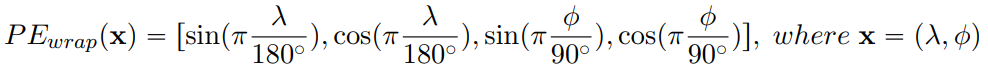

Mac Aodha et al. (2019)

In [ ]:
# Compute the sin and cos components
df['lon_sin'] = np.sin(np.pi * df['centroid_lon'] / 180.0)
df['lon_cos'] = np.cos(np.pi * df['centroid_lon'] / 180.0)

df['lat_sin'] = np.sin(np.pi * df['centroid_lat'] / 90.0)
df['lat_cos'] = np.cos(np.pi * df['centroid_lat'] / 90.0)

# Add the computed components to the DF
df[[
    'geometry_wkt',
    'centroid_lon',
    'lon_sin',
    'lon_cos',
    'centroid_lat',
    'lat_sin',
    'lat_cos']].head()

,geometry_wkt,centroid_lon,lon_sin,lon_cos,centroid_lat,lat_sin,lat_cos
3,"POLYGON ((5.87 55.06, 5.87 47.26, 15.05 47.26,...",9.542000,0.165771,0.986164,51.940000,0.970800,-0.239889
4,"POLYGON ((5.11 55.11, 5.11 46.99, 15.69 46.99,...",9.342000,0.162327,0.986737,51.862000,0.971450,-0.237245
10,"POLYGON ((13.3692550344182 53.7189306780194, 1...",13.389488,0.231569,0.972818,53.709726,0.954139,-0.299365
15,"POLYGON ((7.51635924957007 49.9805208816045, 7...",7.517514,0.130829,0.991405,49.979743,0.984930,-0.172952
16,"POLYGON ((7.3784948030498 52.908738040868, 7.3...",7.379336,0.128438,0.991718,52.908154,0.962140,-0.272554


In [ ]:
# Extract spatial features
spatial_features_np = df[[
    'lon_sin','lon_cos',
    'lat_sin','lat_cos']].values.astype(np.float32)

print("Spatial encoding complete!")
print(f"Sample:\n{spatial_features_np[0:5, :]}")
print(f"Shape: {spatial_features_np.shape}")

Spatial encoding complete!
Sample:
[[ 0.16577055  0.98616433  0.9708003  -0.23988919]
 [ 0.16232719  0.986737    0.97144985 -0.23724508]
 [ 0.23156942  0.9728184   0.95413876 -0.29936475]
 [ 0.13082924  0.9914049   0.9849303  -0.17295179]
 [ 0.12843794  0.9917176   0.96214044 -0.27255413]]
Shape: (300765, 4)


In [ ]:
# Save sinusoidal tensor to Drive as data array
np.save(
    os.path.join(SAVE_DIR, 'sinu_spatial_features.npy'),
    spatial_features_np)

print("Sinu spatial encoding saved!")


Sinu spatial encoding saved!


### 2D Coordinates

In [ ]:
# Convert degree to radians
spatial_2d_rad = np.radians(df[['centroid_lat', 'centroid_lon']].values)

print("Spatial encoding complete!")
print(f"Sample:\n{spatial_2d_rad[0:5, :]}")

Spatial encoding complete!
Sample:
[[0.90652401 0.16653932]
 [0.90516266 0.16304866]
 [0.93741157 0.23369065]
 [0.87231108 0.13120536]
 [0.9234215  0.12879371]]


In [ ]:
rad_min = spatial_2d_rad.min()
rad_max = spatial_2d_rad.max()
print(f"Radian range: {rad_min:.4f} to {rad_max:.4f}")

Radian range: -3.1416 to 3.1416


In [ ]:
np.save(
    os.path.join(SAVE_DIR, '2d_spatial_features.npy'),
    spatial_2d_rad)

print("2D spatial encoding saved!")

2D spatial encoding saved!


## Temporal

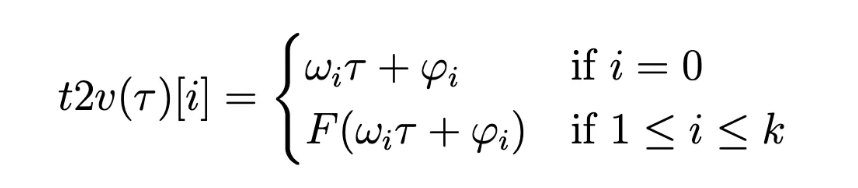

Kazemi et al. 2019

In [ ]:
import torch
import torch.nn as nn

### Time2Vec

In [ ]:
class Time2Vec(nn.Module):
    """
    Implementation of T2V following the paper of Kazemi et al. (2019)
    """
    def __init__(self, input_dim: int = 1, embedded_dim: int = 16):
        super(Time2Vec, self).__init__()

        self.k = embedded_dim

        self.w0 = nn.parameter.Parameter(torch.randn(input_dim, 1))
        self.b0 = nn.parameter.Parameter(torch.randn(1))

        self.w = nn.parameter.Parameter(torch.randn(input_dim, self.k - 1))
        self.b = nn.parameter.Parameter(torch.randn(self.k - 1))

        self.f = torch.sin

    def forward(self, t):
        v_linear = torch.matmul(t, self.w0) + self.b0
        v_perodic = self.f(torch.matmul(t, self.w) + self.b)

        return torch.cat([v_linear, v_perodic], -1)

In [ ]:
# Convert date-time data into numerical scalar
df['startDate_epoch'] = ((df['temporal_startDate']
                          .astype(np.int64))/1000000000).astype(np.float32)

df['endDate_epoch'] = ((df['temporal_endDate']
                        .astype(np.int64))/1000000000).astype(np.float32)

start_time_tensor = torch.from_numpy(df['startDate_epoch'].values).unsqueeze(1)
end_time_tensor = torch.from_numpy(df['endDate_epoch'].values).unsqueeze(1)

print(f"Start time tensor: {start_time_tensor.shape}")
print(f"End time tensor: {end_time_tensor.shape}")

Start time tensor: torch.Size([300765, 1])
End time tensor: torch.Size([300765, 1])


In [ ]:
EMBED_DIM = 16 # 1 linear, 15 periodic

# T2V class instantiation
T2V_start = Time2Vec(input_dim=1, embedded_dim=EMBED_DIM)
T2V_end = Time2Vec(input_dim=1, embedded_dim=EMBED_DIM)

# Encoding
with torch.no_grad():
    start_time_encoded = T2V_start(start_time_tensor)
    end_time_encoded = T2V_end(end_time_tensor)

    temporal_features_tensor = torch.cat(
        [start_time_encoded, end_time_encoded],
        dim=-1)

print(f"Complete temporal vector:\n{temporal_features_tensor[0:5, :]}")
print(f"Complete temporal vector shape: {temporal_features_tensor.shape}")

Complete temporal vector:
tensor([[-2.7207e+09,  5.1097e-01, -6.4379e-01, -7.3196e-01,  2.4955e-01,
         -9.7060e-01,  1.7690e-01,  9.2674e-01, -3.8261e-01,  2.6259e-01,
         -7.5724e-01, -7.5232e-01,  9.9668e-01, -5.2171e-01, -9.9677e-01,
          9.5401e-01,  5.7679e+08,  8.7628e-01, -1.8710e-01, -5.9541e-01,
         -7.9783e-01,  9.2467e-01, -9.7105e-01,  7.7517e-01,  9.9835e-01,
          4.1366e-01,  1.9551e-01,  7.8081e-01,  8.6132e-01,  9.2979e-01,
          9.1507e-01, -7.3181e-01],
        [-3.4189e+09, -6.2168e-01, -8.4704e-01,  8.1251e-01,  6.5432e-01,
         -9.4963e-01,  8.9278e-01,  7.5925e-01,  3.0337e-01, -9.4447e-01,
          4.1019e-01, -9.1048e-01,  9.5257e-01, -7.6089e-01, -8.3142e-01,
          9.9950e-01,  7.3843e+08,  7.5448e-01, -8.5642e-01, -2.0751e-01,
         -8.7586e-01, -7.6772e-01, -7.9915e-01,  8.4819e-01,  3.9197e-02,
          1.3649e-01, -7.5336e-01, -9.4294e-01,  3.3073e-01,  3.3329e-01,
         -1.4755e-01, -5.6058e-01],
        [-1.48

In [ ]:
# Save temporal encoding
np.save(
    os.path.join(SAVE_DIR, 't2v_temporal_features.npy'),
    temporal_features_tensor.numpy())
print("T2V temporal features saved!")

T2V temporal features saved!


### Convert to Day Epoch

In [ ]:
# Convert datetime to nanoseconds
start_nano = df['temporal_startDate'].astype(np.int64)
end_nano = df['temporal_endDate'].astype(np.int64)

print(f"temporal_startDate: {df['temporal_startDate']}")
print(f"temporal_endDate: {df['temporal_endDate']}")
print(f"Start time: {start_nano}")
print(f"End time: {end_nano}")

temporal_startDate: 3        2012-03-06 00:00:00+00:00
4        2023-01-01 00:00:00+00:00
10       1993-01-20 00:00:00+00:00
15       2009-04-29 00:00:00+00:00
16       1993-05-31 00:00:00+00:00
                    ...           
917453   1991-11-19 10:35:00+00:00
917455   2006-09-02 05:31:00+00:00
917456   2000-01-05 02:24:00+00:00
917458   1991-11-19 19:23:00+00:00
917460   1996-03-19 07:12:00+00:00
Name: temporal_startDate, Length: 300765, dtype: datetime64[ns, UTC]
temporal_endDate: 3        2012-03-06 00:00:00+00:00
4        2023-12-31 00:00:00+00:00
10       1993-01-20 00:00:00+00:00
15       2014-02-21 00:00:00+00:00
16       1993-05-31 00:00:00+00:00
                    ...           
917453   1991-11-19 10:35:00+00:00
917455   2006-09-29 11:47:00+00:00
917456   2000-12-14 12:00:00+00:00
917458   1991-11-19 19:23:00+00:00
917460   1996-12-09 02:24:00+00:00
Name: temporal_endDate, Length: 300765, dtype: datetime64[ns, UTC]
Start time: 3         1330992000000000000
4         1672

In [ ]:
min_ts = start_nano.min()

# From nanoseconds to days
df['start_days'] = ((start_nano - min_ts) / (1e9 * 86400)).astype(np.float32)
df['end_days'] = ((end_nano - min_ts) / (1e9 * 86400)).astype(np.float32)

print(f"Max start time: {df['start_days'].max()}")
print(f"Min start time: {df['start_days'].min()}")
print(min_ts)

Max start time: 13141.0
Min start time: 0.0
631152020000000000


In [ ]:
epoch_temporal_features = np.column_stack((df['start_days'], df['end_days']))
epoch_temporal_features.shape

(300765, 2)

In [ ]:
epoch_temporal_features[0:5]

array([[ 8100.    ,  8100.    ],
       [12053.    , 12417.    ],
       [ 1114.9998,  1114.9998],
       [ 7058.    ,  8817.    ],
       [ 1245.9998,  1245.9998]], dtype=float32)

In [ ]:
# Scale the values to (-1, 1)
scaler_tp = MinMaxScaler(feature_range=(-1, 1))
scaled_temporal_array = scaler_tp.fit_transform(epoch_temporal_features)

scaled_temporal_array[0:5]

array([[ 0.23278296, -0.8300333 ],
       [ 0.8344115 , -0.7394471 ],
       [-0.8303021 , -0.97660387],
       [ 0.07419527, -0.8149881 ],
       [-0.81036454, -0.973855  ]], dtype=float32)

In [ ]:
tr_range = scaled_temporal_array.max() - scaled_temporal_array.min()
print(f"Temporal range: {tr_range:.2f}")

Temporal range: 2.00


In [ ]:
np.save(os.path.join(
    SAVE_DIR,
    'epoch_temporal_features.npy'),
    scaled_temporal_array)

print("Epoch temporal features saved!")

Epoch temporal features saved!


## Topical

In [ ]:
# Convert the textual columns into a list of strings
text_list = df['text'].tolist()

print(f"Total number of texts: {len(text_list)}")
print(f"First sample: {text_list[0]}")

Total number of texts: 300765
First sample: Berichterstattung Artikel 4/5 der EG-Hochwasserrisikomanagementrichtlinie PFRA_FL | Die Bundesanstalt für Gewässerkunde nimmt im Auftrag des BMU die elektronische WISE-Berichterstattung zur EG-Hochwasserrisikomanagementrichtlinie wahr. Hier wird die Berichterstattung zum Artikel 4 und 5 der EG-Hochwasserrisikomanagementrichtlinie realisiert. Das Shape-File enthält die Örtlichkeiten zum Preliminary Flood Risk Assessment (PFRA). | HWRM-RL. FD. Flood Directive. Floods Directive. EG-Hochwasserrisikomanagementrichtlinie. Hochwasserrisikomanagementrichtlinie. EU-Hochwasserrisikomanagementrichtlinie. Umweltüberwachung. EU-Wasserschutzrichtlinie


In [ ]:
# Initiate the encoding model
model = SentenceTransformer('all-mpnet-base-v2')
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 384, 'do_lower_case': False, 'architecture': 'MPNetModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [ ]:
# Generate embeddings
topical_features_tensor = model.encode(
    text_list,
    batch_size=256,
    show_progress_bar=True,
    convert_to_tensor=True
)

print(f"Topical embeddings shape: {topical_features_tensor.shape}")
print(f"First sample:\n {topical_features_tensor[0]}")

Batches:   0%|          | 0/1175 [00:00<?, ?it/s]

Topical embeddings shape: torch.Size([300765, 768])
First sample:
 tensor([-4.2638e-02, -6.0235e-02, -1.1306e-02,  2.3490e-02, -4.3273e-02,
         2.6423e-03,  6.4008e-03, -8.6248e-02,  2.5787e-03,  3.0366e-02,
         2.3953e-02, -5.8459e-02, -8.8912e-04,  9.0295e-02,  6.9567e-04,
        -4.2509e-02,  4.8491e-03, -3.7660e-02, -8.5219e-03,  2.8405e-02,
         4.9180e-02, -3.2071e-02,  1.3724e-02,  1.8101e-02,  1.0110e-02,
         6.8646e-02, -6.2368e-03,  1.4931e-02, -2.7695e-02, -5.3719e-02,
         8.2625e-02,  6.6156e-03,  2.0062e-02, -4.3658e-02,  2.7554e-06,
        -1.7281e-02, -1.9593e-03, -4.3970e-04,  5.5984e-02,  4.3244e-02,
        -1.7879e-02, -3.4239e-02, -2.7267e-02, -3.7944e-02,  6.7927e-03,
         3.7149e-02, -3.7698e-02,  3.9629e-02,  1.4369e-02,  2.4896e-03,
        -7.0637e-03, -2.9840e-02,  3.2774e-03,  8.0822e-03,  7.1865e-03,
         6.3514e-03, -7.5091e-04,  1.2864e-02,  6.4606e-04,  4.9306e-02,
        -3.1208e-02,  4.9427e-02,  2.6757e-02,  2.1487e-0

In [ ]:
# Save topical encoding
np.save(
    os.path.join(SAVE_DIR, 'topical_features.npy'),
    topical_features_tensor.cpu().numpy())
print("Topical features saved!")

Topical features saved!
